In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("Reddit_Data.csv")
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: >

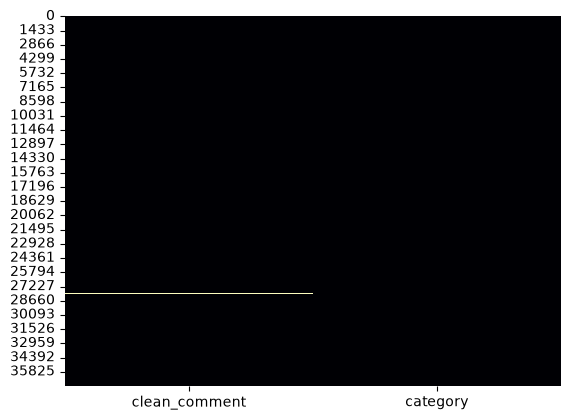

In [4]:
sns.heatmap(df.isnull(),cmap="magma",cbar=False)

In [5]:
df.dropna(inplace= True)

In [6]:
df.duplicated().sum()

np.int64(350)

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df[df["clean_comment"].str.strip() == ""]

,clean_comment,category
181,,0
4432,\n,0
10592,,0
16173,,0
32149,\n,0
34959,,0


In [9]:
df = df[~(df["clean_comment"].str.strip() == "")]

In [10]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer 

In [11]:
def preprocess_comment(comment):
    comment = comment.lower().strip()
    # pungtuation
    comment = ' '.join([re.sub("[^A-Za-z0-9\s?!.,|*]",' ',word) for word in comment.split()])
    # stopwords
    STOPWORDS = set(stopwords.words("english")) -{'not','no','yes','yet','however','but'}  # exception this stopwords--{'not','no','yes','yet','however','but'}
    comment = ' '.join([word for word in comment.split() if word not in STOPWORDS])
    # Lemmatizer
    lemmatizer = WordNetLemmatizer()
    comment = ' '.join([lemmatizer.lemmatize(word) for word in comment.split()])

    return comment

In [12]:
df["clean_comment"] = df["clean_comment"].apply(preprocess_comment)

In [13]:
df.head()

,clean_comment,category
0,family mormon never tried explain still stare ...,1
1,buddhism much lot compatible christianity espe...,1
2,seriously say thing first get complex explain ...,-1
3,learned want teach different focus goal not wr...,0
4,benefit may want read living buddha living chr...,1


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36793 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_comment  36793 non-null  object
 1   category       36793 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 862.3+ KB


In [15]:
df["category"] = df['category'].map({-1: 0, 0: 1, 1: 2})

In [16]:
df["category"].unique()

array([2, 0, 1])

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.model_selection import train_test_split,cross_val_predict ,GridSearchCV,StratifiedKFold
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix

In [18]:
X = df.iloc[:,0]
y = df.iloc[:,1]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [17]:
rf_model = RandomForestClassifier()

In [18]:
def CountVector_featureSelection(X_train,X_test,y_train,y_test,max_features, ngram_range, algo):
    
    count_vectorizer = CountVectorizer(max_features = max_features,ngram_range = ngram_range)
    X_train_transform = count_vectorizer.fit_transform(X_train).toarray()
    X_test_transform = count_vectorizer.transform(X_test).toarray()

    param_grid = {
    'n_estimators': [50, 100, 200,250],
    'max_depth': [4, 6, 8,12,14,16]
    }
    grid_search = GridSearchCV(estimator= algo,param_grid = param_grid,cv=3,scoring= 'accuracy')

    grid_search.fit(X_train_transform, y_train)
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Best CV Score: {grid_search.best_score_:.4f}")
    
    # 4. Evaluate on test set
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_transform)
    test_acc = accuracy_score(y_test, y_pred)
    print(f"Test Accuracy: {test_acc:.4f}")
    
    return best_model, count_vectorizer

In [19]:
CountVector_featureSelection(X_train,X_test,y_train,y_test,max_features=1000,ngram_range=(1,2),algo=rf_model)

Best Parameters: {'max_depth': 16, 'n_estimators': 250}
Best CV Score: 0.6666
Test Accuracy: 0.6656


(RandomForestClassifier(max_depth=16, n_estimators=250),
 CountVectorizer(max_features=1000, ngram_range=(1, 2)))

In [20]:
from sklearn.pipeline import Pipeline

def CountVector_pipeline_search(X_train, X_test, y_train, y_test, algo):
    pipe = Pipeline([
        ('vec', CountVectorizer()),
        ('clf', algo)
    ])

    param_grid = {
        'vec__max_features': [1000, 2000, 5000],
        'vec__ngram_range': [(1, 1), (1, 2),(1,3)],
        'clf__n_estimators': [50, 100, 200,250],
        'clf__max_depth': [4, 8, 14,16,20]
    }

    grid_search = GridSearchCV(pipe, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train, y_train)

    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Best CV score: {grid_search.best_score_}")
    
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    test_acc = accuracy(y_test,y_pred)
    print(f"Test Accuracy: {test_acc:.4f}")
    
    classification_rep = classification_report(y_test,y_pred, output_dict= True)
    print(f"Classification Report:\n{classification_rep}")
    
    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    return best_params

In [21]:
CountVector_pipeline_search(X_train,X_test,y_train,y_test,algo=rf_model)

KeyboardInterrupt: 

In [ ]:
def TfidfVector_pipeline_search(X_train,X_test,y_train,y_test, algo):
    
    pipe = Pipeline([
        ('vec', TfidfVectorizer()),
        ('clf', algo)
    ])

    param_grid = {
        'vec__max_features': [1000, 2000, 5000],
        'vec__ngram_range': [(1, 1), (1, 2),(1,3)],
        'clf__n_estimators': [50, 100, 200,250],
        'clf__max_depth': [4, 8, 14,16,20]
    }
    grid_search = GridSearchCV(estimator= algo,param_grid = param_grid,cv=5,scoring= 'accuracy')
    grid_search.fit( X_train,y_train)
    
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Best CV score: {grid_search.best_score_}")

    best_model = grid_search.best_estimator_
    y_pred = best_params.predict(X_test)
    test_acc = accuracy(y_test,y_pred)
    print(f"Test Accuracy: {test_acc:.4f}")
    
    classification_rep = classification_report(y_test,y_pred, output_dict= True)
    print(f"Classification Report:\n{classification_rep}")
    
    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    
    return best_params

In [ ]:
TfidfVector_pipeline_search(X_train,X_test,y_train,y_test, rf_model)

In [20]:
tfidf_vectorizer = TfidfVectorizer(max_features=1000, ngram_range=(1,3))
X_train_transform = tfidf_vectorizer.fit_transform(X_train).toarray()
X_test_transform = tfidf_vectorizer.transform(X_test).toarray()

In [21]:
X_test_transform

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(7359, 1000))

In [22]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_transform,y_train = smote.fit_resample(X_train_transform,y_train)

In [23]:
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 1. Define Pipelines
pipelines = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),  # Recommended for Logistic Regression
        ("classifier", LogisticRegression(random_state=42, max_iter=1000)),
    ]),
    "Random Forest": Pipeline([
        ("classifier", RandomForestClassifier(n_estimators=250,max_depth=16,random_state=42,n_jobs=-1)),
    ]),
    "XGBoost": Pipeline([
        ("classifier", XGBClassifier(random_state=42, eval_metric="logloss",n_jobs=-1,)),
    ]),
    "LightGBM": Pipeline([
        ("classifier", LGBMClassifier(objective= "multiclass",num_class = 3,metric="multi_logloss",
                                      reg_alpha=0.1,reg_lambda=0.1,learning_rate= 0.09,n_estimators=350,max_depth=20))
    ])
}

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
# 2. Train, Evaluate, and Collect Results
results = []

for name, model in pipelines.items():
    # Fit model
    model.fit(X_train_transform, y_train)
    y_pred = model.predict(X_test_transform)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    # cv_mean = np.mean(cross_val_score(model,X_train_transform, y_train, cv=skf,scoring="accuracy",n_jobs=-1))

    results.append({
        "Model": name,
        "Test Accuracy": acc,
        # "5-Fold CV Mean": cv_mean,
    })

    print(f"\n{'='*20} {name} {'='*20}")
    print(f"Test Accuracy : {acc:.4f}")
    print(f"CV Mean Acc   : {cv_mean:.4f}\n")
    print("Classification Report:")
    # Set output_dict=False for clean, formatted text output
    print(classification_report(y_test, y_pred))

    # Confusion Matrix Plot
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{name} - Confusion Matrix")
    plt.tight_layout()
    plt.show()

# 3. Display Overall Comparison Table
summary_df = pd.DataFrame(results).sort_values(by="Test Accuracy", ascending=False)
print("\n" + "="*50)
print("MODEL COMPARISON SUMMARY")
print("="*50)
print(summary_df.to_string(index=False))


==================== Logistic Regression ====================
Test Accuracy : 0.7795


NameError: name 'cv_mean' is not defined

In [25]:
lightgbm_model = LGBMClassifier(objective= "multiclass",num_class = 3,metric="multi_logloss",
                                reg_alpha=0.1,reg_lambda=0.1,learning_rate= 0.09,n_estimators=350,max_depth=20)

lightgbm_model.fit(X_train_transform,y_train)
y_pred = lightgbm_model.predict(X_test_transform)
accuracy = accuracy_score(y_test,y_pred)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.173430 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 99521
[LightGBM] [Info] Number of data points in the train set: 37851, number of used features: 980
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

In [29]:
import pickle, os

os.makedirs("models", exist_ok=True)

with open("models/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf_vectorizer, f)

with open("models/lightgbm_model.pkl", "wb") as f:
    pickle.dump(lightgbm_model, f)